In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
train = pd.read_csv('/kaggle/input/titanic/train.csv')

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv


First I will  split the data between variable and targets. I will also remove the columns PassenderId, Name, Ticket (these should not have any effect on whether the passenger survived or not) and Cabin (as these have a lot of missing values). I will also remove the embarked column as where the passenger has left from shouldn't have any effect on whether they survived or not.

In [2]:
y = train['Survived']
train.drop(labels = ['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1, inplace = True)
train['Age'].fillna(train['Age'].mean(), inplace = True)
categorical_columns = ['Sex']
train = pd.get_dummies(train,columns = categorical_columns, dtype = int)
train.drop(labels = ['Sex_male'], axis = 1, inplace = True)

X = []
for column in train.columns:
    X.append(column)

X = train[X]

In [3]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female
0,3,22.000000,1,0,7.2500,0
1,1,38.000000,1,0,71.2833,1
2,3,26.000000,0,0,7.9250,1
3,1,35.000000,1,0,53.1000,1
4,3,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,0
887,1,19.000000,0,0,30.0000,1
888,3,29.699118,1,2,23.4500,1
889,1,26.000000,0,0,30.0000,0


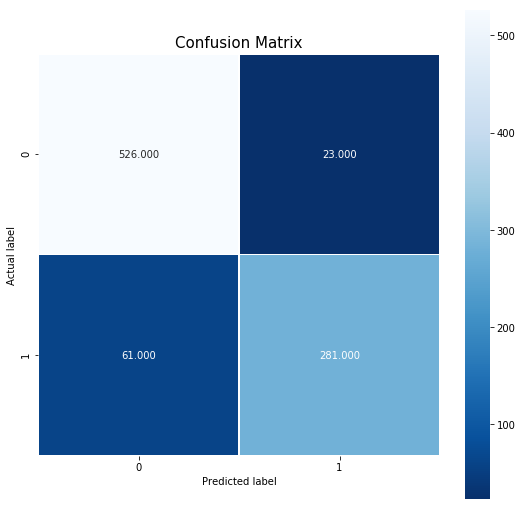

In [4]:
#ENTER MODEL HERE
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(X,y)

y_pred = model.predict(X)

from sklearn import metrics

cm = metrics.confusion_matrix(y, y_pred)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Confusion Matrix'
plt.title(all_sample_title, size = 15);

**Using the model on the test data**

In [5]:
original_test = pd.read_csv('/kaggle/input/titanic/test.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
test.drop(labels = ['PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1, inplace = True)
test['Age'].fillna(test['Age'].mean(), inplace = True)
categorical_columns = ['Sex']
test = pd.get_dummies(test,columns = categorical_columns, dtype = int)
test.drop(labels = ['Sex_male'], axis = 1, inplace = True)
test['Fare'].fillna(test['Fare'].mean(), inplace = True)

test_pred = model.predict(test)
#list_of_predictions_test = []

#for pred in test_pred:
#    list_of_predictions_test.append(one_or_zero(pred))
    
#test_pred = np.asarray(list_of_predictions_test)

In [6]:
submission = pd.DataFrame({
        "PassengerId": original_test["PassengerId"],
        "Survived": test_pred
    }) 

filename = 'submission.csv'
submission.to_csv(filename,index=False)
print('Saved file: ' + filename)

Saved file: submission.csv
